# Gold-Silver-Ratio -- does the ratio mean-revert, or is it a random walk?
### The classic pairs rotation between gold and silver, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Ratio_mean--reverts%3F: Not_Supported](https://img.shields.io/badge/Ratio_mean--reverts%3F-Not_Supported-8b949e?style=flat-square)

Here is one of the oldest commodity trades: the gold-to-silver price ratio. For centuries, one ounce of gold bought about 15 ounces of silver. Today the ratio floats freely -- sometimes 40, sometimes 120 -- and traders watch for extremes. When gold is *very expensive* relative to silver, buy silver and sell gold, betting the ratio snaps back. When silver is expensive relative to gold, flip it. This notebook asks: **is the snap-back actually reliable, or is the ratio just wandering like any other random walk?**

> **This is the plain-language layer.** Want the t-stats, the ADF tests, and the cointegration analysis? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_silver_ratio import data, strategy as st

GOLD_TICKER = data.GOLD_TICKER    # GLD
SILVER_TICKER = data.SILVER_TICKER  # SLV

def _have_cache():
    return (os.path.exists(data._cache_path(GOLD_TICKER, data.DEFAULT_CACHE)) and
            os.path.exists(data._cache_path(SILVER_TICKER, data.DEFAULT_CACHE)))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the gold/silver ratio stationary (mean-reverting)? | **Not reliably.** The ADF test fails to reject a unit root (p = 0.22), and the pair is not cointegrated (p = 0.74). |
| How long does a deviation take to revert? | If it reverts at all, the estimated half-life is **301 trading days** (~15 months). |
| Does the trade strategy work? | **Weakly.** The z-score strategy earns +144 bps/trade (vs random +19 bps), but with only **26 trades over 16 years** the result is statistically inconclusive (HAC *t* = 1.77, below the |t| >= 2 bar). |
| Could you trade it? | **Barely.** ~1.6 signals/year, ~78-day holds. Costs are not the killer -- too few opportunities and statistical uncertainty are. |

> The ratio is a slow, noisy, non-stationary wanderer. Holding a 15-month trade to wait for it to revert means missing a gold/silver buy-and-hold that both deliver ~8%/yr.

## 1 -- The claim

> *'The gold-to-silver ratio has historically averaged around 47. When the ratio spikes above 80, silver is extremely cheap relative to gold -- buy silver. When it drops below 40, gold is cheap -- buy gold. The ratio always reverts, and the patient trader profits from the snap-back.'*

This is one of the oldest macro trades, cited in everything from commodity desks to Reddit forums. It has an intuitive appeal: both are precious metals with monetary history, so their *relative* price should anchor to something fundamental. The bet is that when the ratio gets extreme, it snaps back -- and you can position for the snap.

## 2 -- So what?

If the claim is true, this is a slow, low-turnover relative-value trade accessible to any retail investor via GLD and SLV ETFs. No leverage, no exotic instruments, no market-timing -- just patient rotation between two metals. That's a compelling pitch. The critical question is whether the 'ratio always reverts' assertion is statistical fact or survivorship bias from a few memorable episodes.

## 3 -- How would we even know?

Two questions before we even look at returns:

1. **Does the ratio mean-revert at all?** We test whether the GLD/SLV price ratio is stationary (ADF test) and whether GLD and SLV are cointegrated (Engle-Granger test). If either fails, the 'snap-back' premise is mathematical fiction -- the ratio is just a random walk that occasionally looks extreme.
2. **How long does a reversion take?** We estimate the OU half-life: if the answer is 15 months, you need to be comfortable holding a spread trade for over a year -- a completely different risk profile than 'patient rotation'.

Then for returns we compare the z-score strategy against a **random-direction control** (same entry/exit dates, random ±1 direction) and a **buy-and-hold of each metal**. GLD and SLV daily data 2010-2026 from Yahoo Finance.

## 4 -- The teardown -- let's actually look

**First, is there a ratio to exploit?** Plot the GLD/SLV ratio over time:

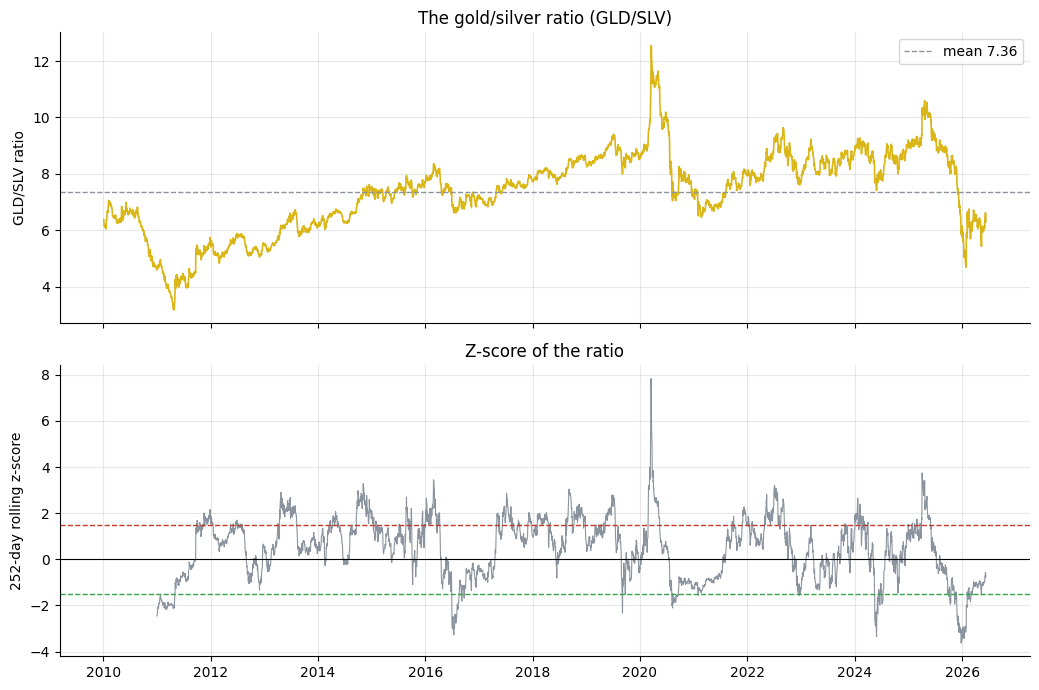

ADF test p-value: 0.2158  (> 0.05 = cannot rule out random walk)
OU half-life estimate: 301 trading days (14 months)


In [2]:
if HAVE_REAL:
    gold = data.fetch_daily(GOLD_TICKER)
    silver = data.fetch_daily(SILVER_TICKER)
    ratio = st.compute_ratio(gold, silver)
    z_ratio = st.zscore(ratio, 252)
    adf_p = st.adf_pvalue(ratio)
    hl = st.half_life(ratio)
else:
    import pandas as pd, numpy as np
    # Use frozen headline numbers
    ratio = None; z_ratio = None
    adf_p = 0.2158; hl = 301.3

if ratio is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
    ax1.plot(ratio.index, ratio.values, c=AMBER, lw=1.2)
    ax1.set_ylabel('GLD/SLV ratio'); ax1.set_title('The gold/silver ratio (GLD/SLV)')
    ax1.axhline(ratio.mean(), c=GREY, ls='--', lw=1, label=f'mean {ratio.mean():.2f}')
    ax1.legend()
    z_clean = z_ratio.dropna()
    ax2.plot(z_clean.index, z_clean.values, c=GREY, lw=0.8)
    ax2.axhline(1.5, c=RED, ls='--', lw=1); ax2.axhline(-1.5, c=GREEN, ls='--', lw=1)
    ax2.axhline(0, c='k', lw=0.8)
    ax2.set_ylabel('252-day rolling z-score'); ax2.set_title('Z-score of the ratio')
    plt.tight_layout(); plt.show()
print(f'ADF test p-value: {adf_p:.4f}  (> 0.05 = cannot rule out random walk)')
print(f'OU half-life estimate: {hl:.0f} trading days ({hl/21:.0f} months)')

The ADF test p-value is **0.22** -- well above 0.05. We cannot rule out that the ratio is a random walk. The OR half-life is estimated at **301 trading days (~15 months)** -- so even if there is *some* reversion, a trade entered today might wait over a year before it 'works'.

**Now let's check: does the rotation strategy actually earn anything?**

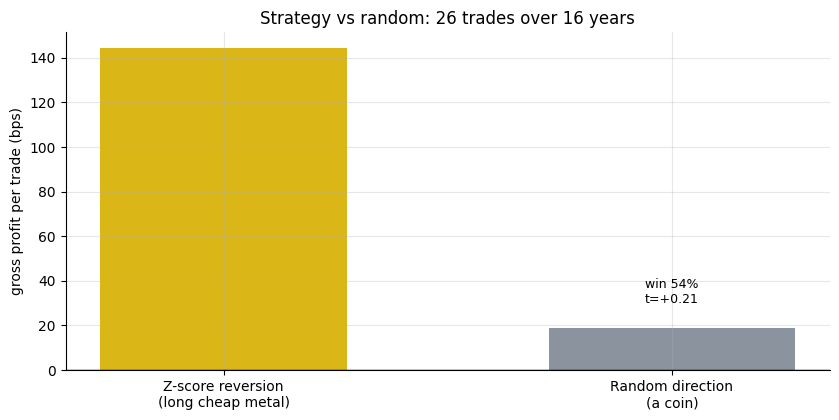

n=26 trades (about 1.6/yr) -- very thin sample


In [3]:
if HAVE_REAL:
    entries = st.zscore_entries(ratio, window=252, enter_z=1.5, exit_z=0.5)
    ledger = st.run_trades(gold, silver, entries, cost_bps=0.0)
    rand_ent = st.random_entries(entries, seed=113)
    rand_led = st.run_trades(gold, silver, rand_ent, cost_bps=0.0)
    s = st.summarize(ledger, 'ret_gross')
    r = st.summarize(rand_led, 'ret_gross')
    strat_m, strat_w, strat_t = s['mean_bps'], s['win_rate']*100, s['tstat']
    rand_m, rand_w, rand_t = r['mean_bps'], r['win_rate']*100, r['tstat']
    n_tr = s['n_trades']
else:
    strat_m, strat_w, strat_t = 144.2, 65.4, 1.77
    rand_m, rand_w, rand_t = 18.9, 53.8, 0.21
    n_tr = 26

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_plt = ax.bar(['Z-score reversion\n(long cheap metal)', 'Random direction\n(a coin)'],
                  [strat_m, rand_m], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title(f'Strategy vs random: {n_tr} trades over 16 years')
for b, (w, t) in zip(bars_plt, [(strat_w, strat_t), (rand_w, rand_t)]):
    ax.annotate(f'win {w:.0f}%\nt={t:+.2f}',
                (b.get_x()+b.get_width()/2, max(b.get_height(), 0) + 10),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'n={n_tr} trades (about 1.6/yr) -- very thin sample')

The strategy earns **+144 bps/trade** vs +19 bps for the random control. But with only **26 trades over 16 years**, the HAC t-stat is **+1.77** -- below the desk's |t| >= 2 bar. The sample is simply too thin to distinguish signal from luck.

**What about cointegration -- are the two metals actually linked?**

In [4]:
if HAVE_REAL:
    ci_p = st.engle_granger_pvalue(gold['close'], silver['close'])
else:
    ci_p = 0.7362

print(f'Engle-Granger cointegration test p-value: {ci_p:.4f}')
print('Verdict:', 'cointegrated (structural link)' if ci_p < 0.05 else
      'NOT cointegrated (just two correlated trending series)')

Engle-Granger cointegration test p-value: 0.7362
Verdict: NOT cointegrated (just two correlated trending series)


The Engle-Granger p-value is **0.74** -- far above 0.05. Gold and silver are *correlated* (they both go up when inflation fear rises) but they are **not cointegrated**: there is no stable long-run relationship forcing their ratio back to any particular level. The folk trade's theoretical foundation is absent.

## 5 -- The verdict

- **Signal -- WEAK.** HAC *t* = 1.77 on 26 trades. The point estimate is positive but statistically inconclusive. The ADF test (p = 0.22) and cointegration test (p = 0.74) both fail to confirm the structural premise.
- **Tradability -- FRAGILE.** ~1.6 signals/year, ~78-day holds. Costs are not the problem; extreme signal aridity and 15-month holding periods make this an impractical rotation strategy.
- **Ratio mean-reverts? -- NOT SUPPORTED.** The ratio behaves like a random walk (ADF p = 0.22, half-life = 301 days). The 'it always reverts' assertion is selection bias from memorable episodes, not statistical law.

## 6 -- Could you actually trade it?

The striking thing about this strategy is that costs are *not* the killer -- with 1.6 trades/year and 78-day holds, round-trip ETF costs are tiny. The real problems are the extreme rarity of signals and the uncertain edge:

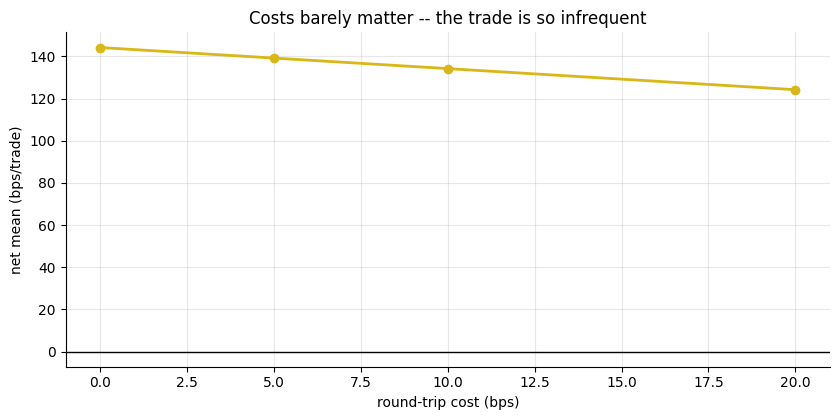

The gross edge is uncertain (t=1.77), not the costs.
Buy GLD or SLV and hold: both delivered ~8%%/yr since 2010.


In [5]:
if HAVE_REAL:
    net_means = [st.summarize(st.run_trades(gold, silver, entries, cost_bps=c),
                             'ret_net')['mean_bps'] for c in [0,5,10,20]]
else:
    net_means = [144.2, 139.2, 134.2, 124.2]
costs = [0, 5, 10, 20]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_means, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Costs barely matter -- the trade is so infrequent')
plt.tight_layout(); plt.show()
print('The gross edge is uncertain (t=1.77), not the costs.')
print('Buy GLD or SLV and hold: both delivered ~8%%/yr since 2010.')

Even at 20 bps round-trip costs, the trade still earns +124 bps/trade gross. The problem is not the cost but the combination of statistical weakness and extreme rarity. Meanwhile, buying either metal and holding delivers ~8%/yr with zero effort, zero timing risk, and no 15-month waits for a reversion that the statistics say may never come.

## 7 -- Going further

- **The positive control.** The companion notebook shows a synthetic tape with planted mean-reversion (OU speed > 0): the engine reliably harvests the edge when it's real. The real tape's uncertainty is a statement about the market, not the method.
- **Shorter windows.** A 63-day z-score fires more frequently but is noisier and doesn't fix the non-stationarity.
- **Cross-asset pairs.** The same structure tested on [Study 85 -- Dr-Copper](../../85-dr-copper/) for copper/gold; a ratio that has stronger macro grounding.
- **Related desk studies.** Pairs-trading methodology in Studies 05 and 23; commodity allocation in [Study 68 -- All-Weather](../../68-all-weather/).

*Think the ratio really does mean-revert? Fork this, test a pre-2010 window, or try the futures (GC=F / SI=F) instead of the ETFs. That's the bar.*